In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

# 1번

주어진 test_1.npy 시계열을 시각화하여 확인하고, 정상성 테스트를 수행한 뒤 정상시계열이 아니면 차분을 적용하여 다시 정상성 테스트를 수행하는 코드를 작성

In [3]:
process = np.load("./data/npy/test_1.npy")

In [4]:
process.shape

(1000,)

In [5]:
len(process)

1000

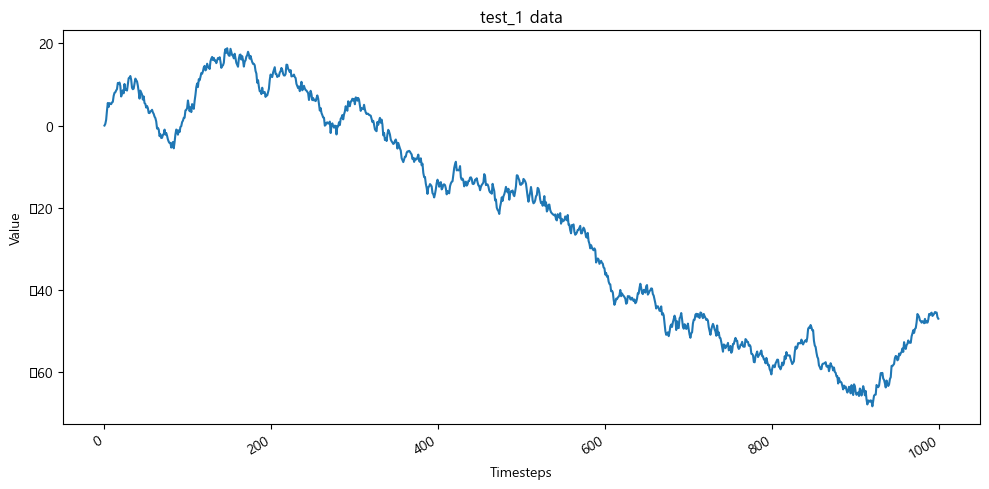

In [6]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(process)
ax.set_title("test_1 data")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [7]:
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -0.5437433594783745
p-value: 0.8831939389121153


- 귀무가설 : 비정상 시계열이다
- 대립가설 : 정상 시계열이다

- p-value가 0.8832이므로 귀무가설을 기각할 수 없으며 test_1 데이터는 비정상 시계열로 판단

In [8]:
# 1차 차분
process_diff = np.diff(process, n = 1)

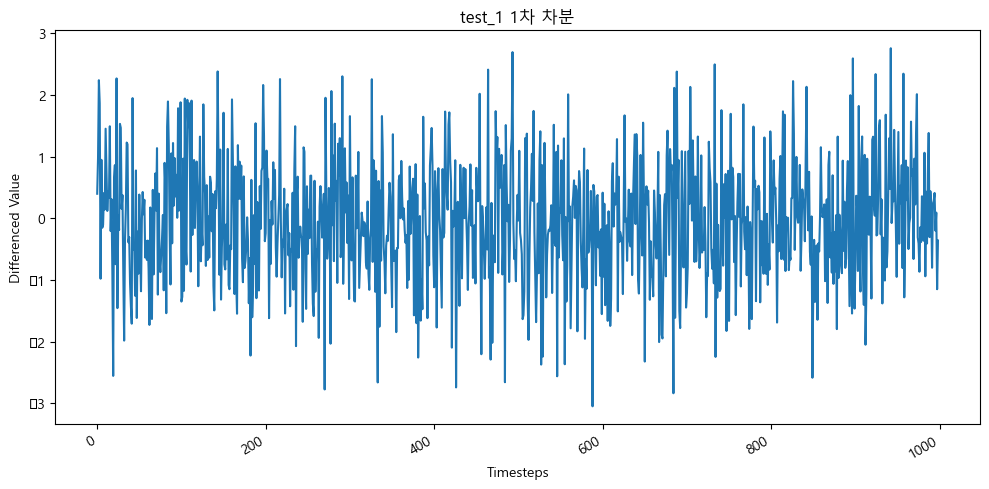

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(process_diff)
ax.set_title("test_1 1차 차분")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Differenced Value")

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [10]:
ADF_diff_result = adfuller(process_diff)

print(f"ADF Statistic: {ADF_diff_result[0]}")
print(f"p-value: {ADF_diff_result[1]}")

ADF Statistic: -32.42488720691621
p-value: 0.0


- p-value가 0.0이기 때문에 귀무가설을 기각하며, 1차 차분된 시계열은 정상 시계열

# 2번

ACF와 PACF를 활용하여 주어진 test_2.npy 시계열이 AR 프로세스인지 MA 프로세스인지 판단하는 코드를 작성하고, 적절한 차수(p 또는 q)를 제시

In [11]:
process = np.load("./data/npy/test_2.npy")

In [12]:
print(process.shape)
print(len(process))

(1000,)
1000


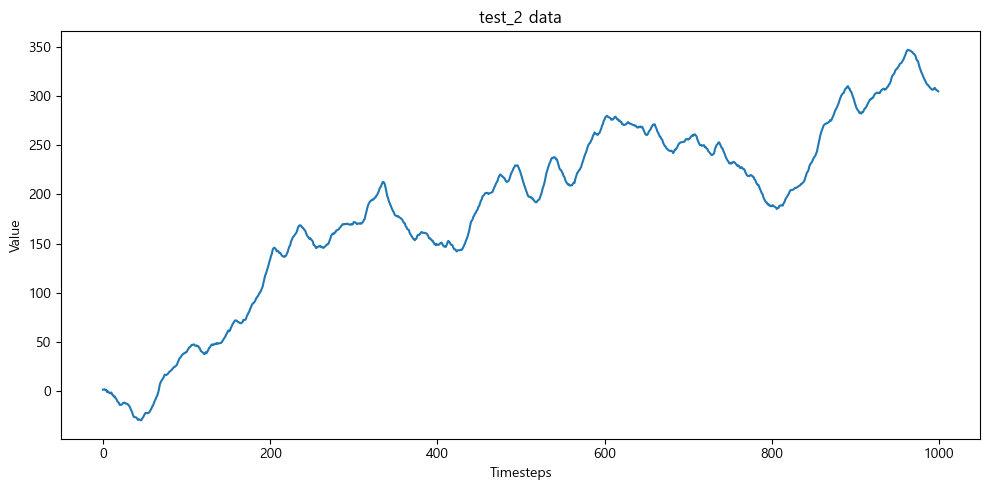

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(process)
ax.set_title("test_2 data")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()

plt.show()

In [14]:
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -1.6587323033632588
p-value: 0.4524903444973913


- p-value가 0.4524로 유의수준보다 크기 때문에 귀무가설을 기각할 수 없음
- test_2 시계열은 비정상 시계열로 판단

In [15]:
# 1차 차분
process_diff = np.diff(process, n = 1)

In [16]:
print(len(process))
print(len(process_diff))

1000
999


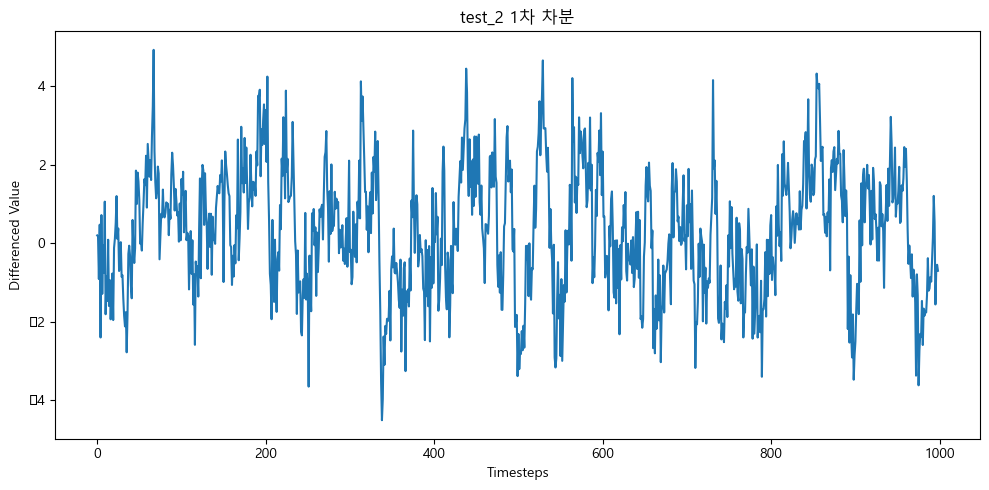

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(process_diff)
ax.set_title("test_2 1차 차분")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Differenced Value")

plt.tight_layout()

plt.show()

In [18]:
ADF_diff_result = adfuller(process_diff)

print(f"ADF Statistic: {ADF_diff_result[0]}")
print(f"p-value: {ADF_diff_result[1]}")

ADF Statistic: -7.583345896189125
p-value: 2.6460503833673994e-11


- p-value가 유의수준보다 작기 때문에 귀무가설을 기각
- 1차 차분된 process_diff는 정상 시계열로 판단

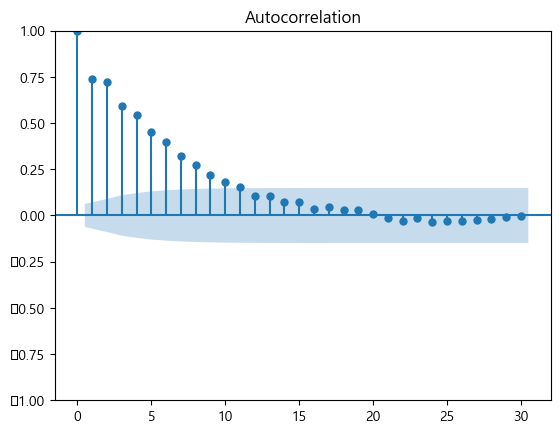

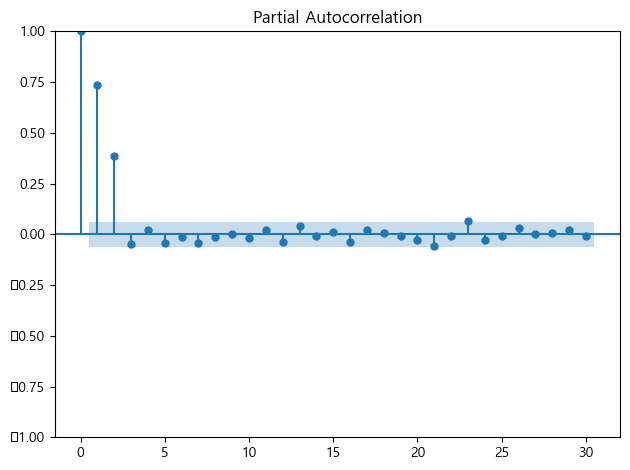

In [19]:
# ACF와 PACF 시각화
# ACF
plot_acf(process_diff, lags=30,)

# PACF
plot_pacf(process_diff, lags=30,)

plt.tight_layout()
plt.show()

- ACF는 Lag 2 이후 서서히 감소하는 형태
- PACF는 신뢰구간을 벗어나는 곳이 존재
    - Lag 2 이후 절단되는 형태입니다
- 1차 차분된 시계열은 AR(2) 프로세스로 판단할 수 있음
- test_2 시계열은 1차 차분 후 정상성이 확보되었으므로 원본 시계열 전체 모델은 ARIMA(2, 1, 0)로 표현 가능
    - p = 2, d = 1, q = 0

# 3번

주어진 bandwidth.csv 데이터의 마지막 168timesteps에 대해 예측을 수행하는 코드를 작성하시오(필수적인 코드만 답안으로 작성)

In [20]:
df = pd.read_csv("./data/csv/bandwidth.csv")

In [21]:
df.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


In [22]:
HORIZON = 168

train = df.iloc[:-HORIZON]
test = df.iloc[-HORIZON:]

In [23]:
train.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


In [24]:
len(train)

9832

In [25]:
test.head()

,hourly_bandwidth
9832,717.176939
9833,711.311745
9834,708.114679
9835,707.024482
9836,707.689774


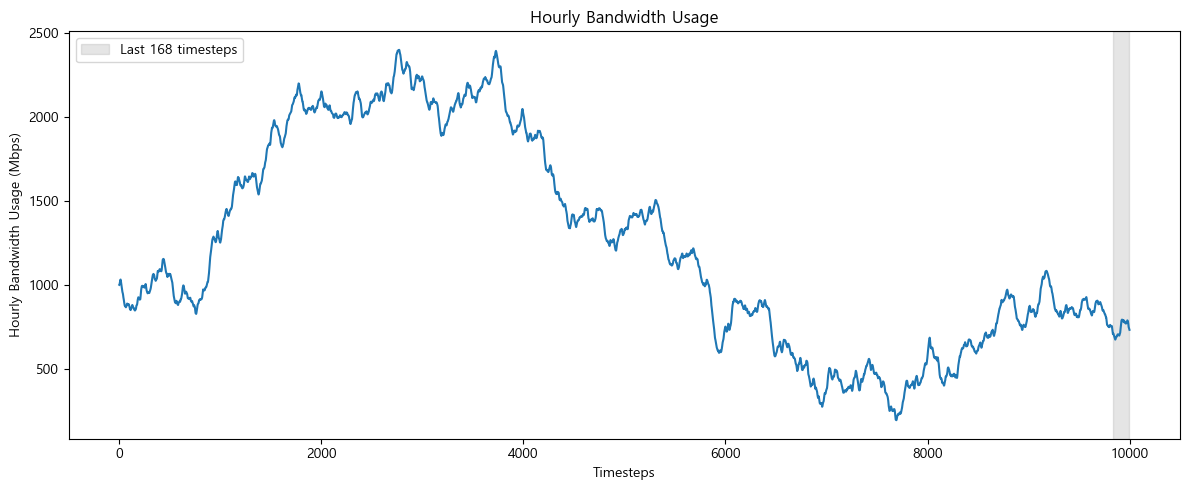

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["hourly_bandwidth"])
ax.axvspan(
    test.index[0],
    test.index[-1],
    color="#808080",
    alpha=0.2,
    label="Last 168 timesteps"
)

ax.set_title("Hourly Bandwidth Usage")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Hourly Bandwidth Usage (Mbps)")
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
ADF_result = adfuller(train)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -0.8222075294644419
p-value: 0.8125115848432024


- p-value가 유의수준보다 크기 때문에 귀무가설 기각 불가능
- train 데이터는 비정상 시계열로 판단

In [28]:
train_diff = train.diff().dropna() # 결측치 오류 발생해서 결측치 제거

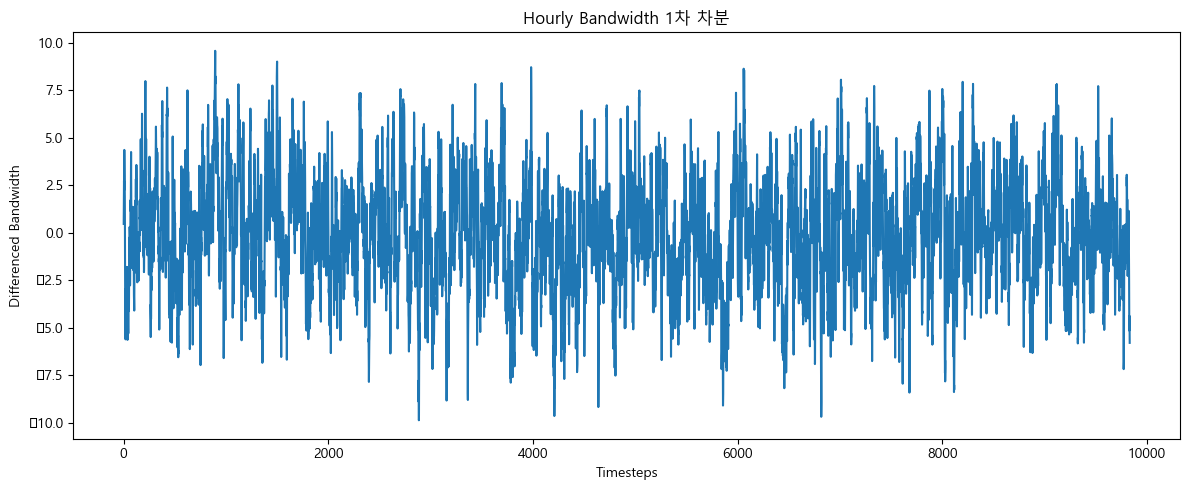

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_diff)
ax.set_title("Hourly Bandwidth 1차 차분")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Differenced Bandwidth")

plt.tight_layout()
plt.show()

In [30]:
ADF_diff_result = adfuller(train_diff)

print(f"ADF Statistic: {ADF_diff_result[0]}")
print(f"p-value: {ADF_diff_result[1]}")

ADF Statistic: -20.526228992356813
p-value: 0.0


- p-value 값이 유의수준보다 작으므로 귀무가설 기각
- d = 1

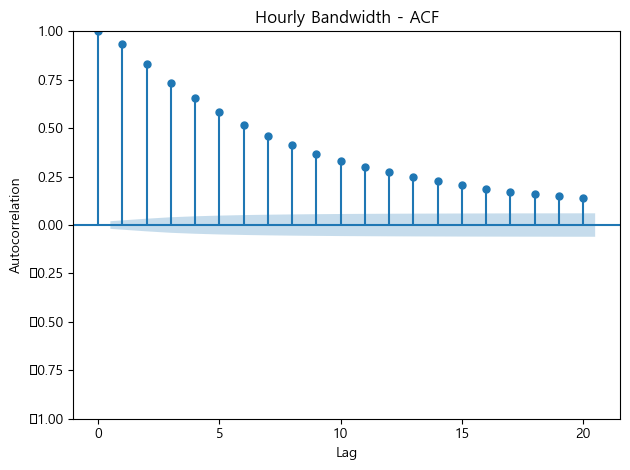

In [31]:
# 1차 차분 데이터의 ACF
plot_acf(train_diff, lags=20)

plt.title("Hourly Bandwidth - ACF")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()

plt.show()

- ACF는 Lag 1에서 매우 높은 양의 자기 상관을 보인 뒤 Lag가 증가할 수록 감소
    - 특정 Lag 이후 갑자기 절단되는 형태는 아님
    - 순수 MA(q) 프로세스의 전형적인 패턴은 아님
    - AR이 강해보임

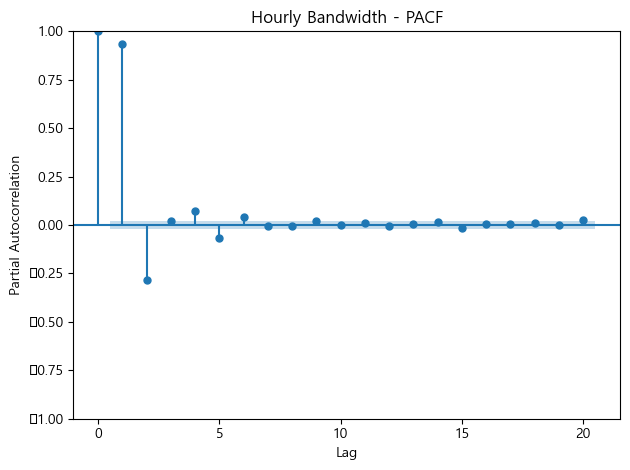

In [32]:
# 1차 차분 데이터의 PACF
plot_pacf(train_diff, lags=20, method="ywm")

plt.title("Hourly Bandwidth - PACF")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()

plt.show()

- Lag 1 : 매우 큰 양의 값
- Lag 2 : 큰 음의 값
- Lag 3 이후 값이 크게 줄어들기는 하지만 일부 유의한 값 존재

- 그래프만 보면 AR(2)를 강력한 후보로 둘 수 있음
- 후보 범위 : p = 0, 1, 2, 3, q = 0, 1, 2 ,3

In [33]:
# AIC로 p, q 비교
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    '''
    endog : 예측하고자 하는 대상 시계열 데이터
    order_list : p, q 조합 리스트
    '''
    results = [] # 차수 p, q와 그에 해당하는 AIC를 저장할 리스트

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order = (order[0], 0, order[1])).fit(disp = False)

        except:
            continue

        aic = model.aic # 모델의 AIC를 계산
        results.append([order, aic]) # 결과 리스트에 p, q 조합과 AIC를 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ["(p, q)", "AIC"]

    # 오름차순 정렬, AIC가 낮을수록 좋음
    result_df = result_df.sort_values(by = "AIC", ascending = True).reset_index(drop = True)

    return result_df

In [34]:
ps = range(0, 4)
qs = range(0, 4)

order_list = list(product(ps, qs))

order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [35]:
result_df = optimize_ARMA(train_diff, order_list)

result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q)",AIC
0,"(3, 2)",27991.063879
1,"(2, 3)",27991.287509
2,"(2, 2)",27991.603598
3,"(3, 3)",27993.416924
4,"(1, 3)",28003.349550
5,"(1, 2)",28051.351401
6,"(3, 1)",28071.155496
7,"(3, 0)",28095.618186
8,"(2, 1)",28097.250766
9,"(2, 0)",28098.407664


In [36]:
# ARMA(2, 2) 적합 및 잔차 검정
model_fit = SARIMAX(train_diff, order = (2, 0, 2)).fit(disp = False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       hourly_bandwidth   No. Observations:                 9831
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -13990.802
Date:                Mon, 20 Jul 2026   AIC                          27991.604
Time:                        15:45:05   BIC                          28027.570
Sample:                             0   HQIC                         28003.788
                               - 9831                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.052      6.765      0.000       0.248       0.450
ar.L2          0.4743      0.047     10.000      0.000       0.381       0.567
ma.L1          0.8667      0.050     17.249      0.0

In [37]:
residuals = model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11))

print(rt)

     lb_stat  lb_pvalue
1   0.042190   0.837257
2   0.418364   0.811247
3   0.520271   0.914416
4   0.850554   0.931545
5   0.850841   0.973678
6   1.111754   0.981019
7   2.124864   0.952607
8   3.230558   0.919067
9   3.248662   0.953615
10  3.588289   0.964015


- 모델의 모든 계수가 통계적으로 유의하고 Ljung-Box 검정에서도 모든 p-value가 유의수준보다 큼
- 잔차에 유의한 자기상관이 남아 있지 않으며, ARMA(2, 2)가 차분 시계열의 구조를 충분히 설명한 것으로 판단

In [38]:
bandwidth_diff = np.diff(df["hourly_bandwidth"], n = 1)

df_diff = pd.DataFrame({"bandwidth_diff" : bandwidth_diff})

diff_train = df_diff.iloc[:-168]
diff_test = df_diff.iloc[-168:]

In [39]:
diff_train.head()

,bandwidth_diff
0,0.472694
1,1.076611
2,2.656099
3,2.745698
4,2.246164


In [40]:
diff_test.head()

,bandwidth_diff
9831,-5.943995
9832,-5.865194
9833,-3.197066
9834,-1.090197
9835,0.665291


In [41]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str, p = 0, q = 0) -> list:
    '''
    df : 전체 시계열 데이터
    train_len : 훈련 집합의 크기
    horizon : 테스트 집합의 크기. 예측할 값의 개수
    window : 한 번에 예측할 timestep 개수
    method : 사용할 모델 지정
    p : AR 프로세스의 차수
    q : MA 프로세스의 차수
    '''
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend([mean] * window)

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)

        return pred_last_value

    elif method == "ARMA":
        pred_ARMA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (p, 0, q))
            res = model.fit(disp = False) # disp : 훈련 과정을 화면에 출력할지 여부
            predictions = res.get_prediction(0, i + window - 1) # start, end
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)

        return pred_ARMA

In [46]:
P = 2
Q = 2
TRAIN_LEN = len(diff_train)
HORIZON = len(diff_test)
WINDOW = 2

In [47]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "mean")
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "last")
pred_ARMA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "ARMA", P, Q)

In [48]:
diff_test.loc[:, "pred_mean"] = pred_mean
diff_test.loc[:, "pred_last_value"] = pred_last_value
diff_test.loc[:, "pred_ARMA"] = pred_ARMA

diff_test.head()

,bandwidth_diff,pred_mean,pred_last_value,pred_ARMA
9831,-5.943995,-0.028214,-5.791207,-5.460661
9832,-5.865194,-0.028214,-5.791207,-4.890626
9833,-3.197066,-0.029410,-5.865194,-5.335905
9834,-1.090197,-0.029410,-5.865194,-4.751731
9835,0.665291,-0.029840,-1.090197,-0.375596


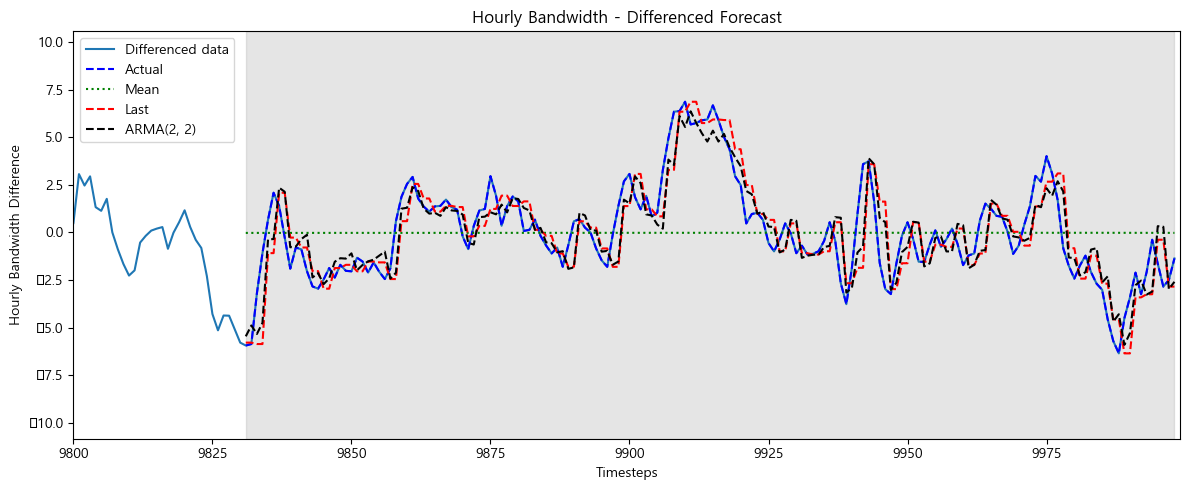

In [51]:
# 차분 시계열 예측 결과 시각화
fig, ax = plt.subplots(figsize = (12, 5))

ax.plot(df_diff["bandwidth_diff"], label = "Differenced data")
ax.plot(diff_test["bandwidth_diff"], "b--", label = "Actual")
ax.plot(diff_test["pred_mean"], "g:", label = "Mean")
ax.plot(diff_test["pred_last_value"], "r--", label = "Last")
ax.plot(diff_test["pred_ARMA"], "k--", label = "ARMA(2, 2)")

ax.axvspan(diff_test.index[0], diff_test.index[-1], color = "#808080", alpha = 0.2)

ax.set_xlim(9800, 9999)

ax.set_title("Hourly Bandwidth - Differenced Forecast")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Hourly Bandwidth Difference")

ax.legend()

plt.tight_layout()

plt.show()

In [52]:
# MSE 계산
mse_mean = mean_squared_error(
    diff_test["bandwidth_diff"],
    diff_test["pred_mean"]
)

mse_last = mean_squared_error(
    diff_test["bandwidth_diff"],
    diff_test["pred_last_value"]
)

mse_ARMA = mean_squared_error(
    diff_test["bandwidth_diff"],
    diff_test["pred_ARMA"]
)

print(f"Mean MSE: {mse_mean}")
print(f"Last value MSE: {mse_last}")
print(f"ARMA(2, 2) MSE: {mse_ARMA}")

Mean MSE: 6.306526957989325
Last value MSE: 2.2297582947733656
ARMA(2, 2) MSE: 1.769046211391861


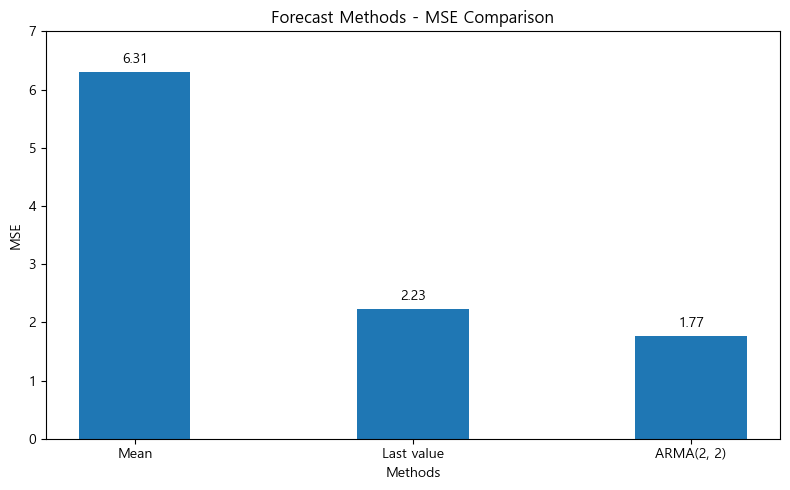

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

methods = [
    "Mean",
    "Last value",
    "ARMA(2, 2)"
]

mse_values = [
    mse_mean,
    mse_last,
    mse_ARMA
]

ax.bar(
    methods,
    mse_values,
    width=0.4
)

ax.set_title("Forecast Methods - MSE Comparison")
ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 7)

# 각 막대 위에 MSE 값 표시
for index, value in enumerate(mse_values):
    ax.text(
        x=index,
        y=value + 0.15,
        s=f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [54]:
# 원본 대역폭 시계열
original_series = df["hourly_bandwidth"]

# 원본 시계열의 마지막 168개 실제값
original_test = original_series.iloc[-HORIZON:].copy()

# 첫 번째 예측 시점 바로 이전의 실제값
base_value = original_series.iloc[
    len(original_series) - HORIZON - 1
]

print(f"기준값 인덱스: {len(original_series) - HORIZON - 1}")
print(f"기준값: {base_value}")
print(f"원본 테스트 시작 인덱스: {original_test.index[0]}")

기준값 인덱스: 9831
기준값: 723.1209335578892
원본 테스트 시작 인덱스: 9832


In [56]:
pred_bandwidth = pd.Series(
    base_value + np.cumsum(diff_test["pred_ARMA"].to_numpy()),
    index=original_test.index,
    name="pred_bandwidth"
)

forecast_result = pd.DataFrame({
    "actual": original_test,
    "pred_ARMA": pred_bandwidth
})

print(f"실제값 개수: {len(original_test)}")
print(f"예측값 개수: {len(pred_bandwidth)}")
print()
forecast_result.head()

실제값 개수: 168
예측값 개수: 168



,actual,pred_ARMA
9832,717.176939,717.660272
9833,711.311745,712.769646
9834,708.114679,707.433741
9835,707.024482,702.682010
9836,707.689774,702.306414


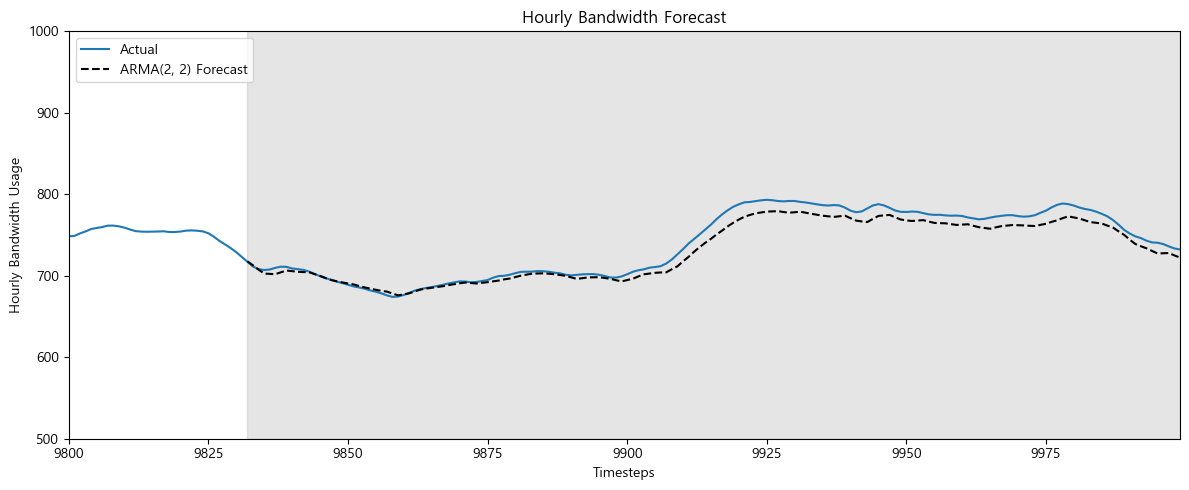

In [58]:
# 원본 테스트 구간 정보
original_test_start = forecast_result.index[0]
original_test_end = forecast_result.index[-1]

fig, ax = plt.subplots(figsize=(12, 5))

# 전체 원본 시계열
ax.plot(
    df["hourly_bandwidth"],
    label="Actual"
)

# 마지막 168 timesteps의 ARMA 예측값
ax.plot(
    forecast_result["pred_ARMA"],
    "k--",
    label="ARMA(2, 2) Forecast"
)

# 테스트 구간 표시
ax.axvspan(
    original_test_start,
    original_test_end,
    color="#808080",
    alpha=0.2
)

# 마지막 테스트 구간 중심으로 확대
ax.set_xlim(
    original_test_start - 32,
    original_test_end
)
ax.set_ylim(500, 1000)

ax.set_title("Hourly Bandwidth Forecast")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Hourly Bandwidth Usage")

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [59]:
# 원본 단위 MAE 계산
mae_ARMA = mean_absolute_error(
    forecast_result["actual"],
    forecast_result["pred_ARMA"]
)

print(f"ARMA(2, 2) MAE: {mae_ARMA}")

ARMA(2, 2) MAE: 8.41225408184884
